# EDA: Tripadvisor European Restaurants Dataset

Análisis exploratorio del dataset de restaurantes europeos de Tripadvisor.

**Objetivos:**
- Explorar estructura y tipos de datos
- Analizar valores faltantes
- Calcular estadísticas descriptivas
- Visualizar distribuciones y relaciones

## 1. Cargar librerías e importar datos

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json

# Configurar estilo
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Ruta del CSV
csv_path = Path('tripadvisor_european_restaurants.csv')
print(f"Cargando: {csv_path}")

# Leer CSV
df = pd.read_csv(csv_path, low_memory=False)
print(f"\nDataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")

Cargando: tripadvisor_european_restaurants.csv

Dataset cargado: 1083397 filas, 42 columnas


## 2. Información General del Dataset

In [5]:
# Mostrar primeras filas
print("Primeras 5 filas:")
df.head()

Primeras 5 filas:


,restaurant_link,restaurant_name,original_location,country,region,province,city,address,latitude,longitude,...,excellent,very_good,average,poor,terrible,food,service,value,atmosphere,keywords
0,g10001637-d10002227,Le 147,"[""Europe"", ""France"", ""Nouvelle-Aquitaine"", ""Ha...",France,Nouvelle-Aquitaine,Haute-Vienne,Saint-Jouvent,"10 Maison Neuve, 87510 Saint-Jouvent France",45.961674,1.169131,...,2.0,0.0,0.0,0.0,0.0,4.0,4.5,4.0,NaN,NaN
1,g10001637-d14975787,Le Saint Jouvent,"[""Europe"", ""France"", ""Nouvelle-Aquitaine"", ""Ha...",France,Nouvelle-Aquitaine,Haute-Vienne,Saint-Jouvent,"16 Place de l Eglise, 87510 Saint-Jouvent France",45.957040,1.205480,...,2.0,2.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
2,g10002858-d4586832,Au Bout du Pont,"[""Europe"", ""France"", ""Centre-Val de Loire"", ""B...",France,Centre-Val de Loire,Berry,Rivarennes,"2 rue des Dames, 36800 Rivarennes France",46.635895,1.386133,...,3.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
3,g10002986-d3510044,Le Relais de Naiade,"[""Europe"", ""France"", ""Nouvelle-Aquitaine"", ""Co...",France,Nouvelle-Aquitaine,Correze,Lacelle,"9 avenue Porte de la Correze 19170, 19170 Lace...",45.642610,1.824460,...,1.0,0.0,0.0,0.0,0.0,4.5,4.5,4.5,NaN,NaN
4,g10022428-d9767191,Relais Du MontSeigne,"[""Europe"", ""France"", ""Occitanie"", ""Aveyron"", ""...",France,Occitanie,Aveyron,Saint-Laurent-de-Levezou,"route du Montseigne, 12620 Saint-Laurent-de-Le...",44.208860,2.960470,...,4.0,7.0,0.0,0.0,0.0,4.5,4.5,4.5,NaN,NaN


In [6]:
# Información de tipos y memoria
print("\nInfo del dataset:")
df.info()


Info del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 1083397 entries, 0 to 1083396
Data columns (total 42 columns):
 #   Column                             Non-Null Count    Dtype  
---  ------                             --------------    -----  
 0   restaurant_link                    1083397 non-null  str    
 1   restaurant_name                    1083396 non-null  str    
 2   original_location                  1083397 non-null  str    
 3   country                            1083397 non-null  str    
 4   region                             1033074 non-null  str    
 5   province                           742765 non-null   str    
 6   city                               682712 non-null   str    
 7   address                            1083397 non-null  str    
 8   latitude                           1067607 non-null  float64
 9   longitude                          1067607 non-null  float64
 10  claimed                            1081555 non-null  str    
 11  awards          

In [7]:
# Dimensiones
print(f"\nForma del dataset: {df.shape}")
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
print(f"\nTamaño en memoria: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


Forma del dataset: (1083397, 42)
Filas: 1,083,397
Columnas: 42

Tamaño en memoria: 1829.97 MB


## 3. Análisis de Valores Faltantes (Missing Values)

In [8]:
# Contar nulos por columna
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_rates = (df.isna().mean() * 100).round(2).sort_values(ascending=False)

# Crear DataFrame de resumen
missing_summary = pd.DataFrame({
    'Columna': missing_counts.index,
    'Nulos_Cantidad': missing_counts.values,
    'Nulos_Porcentaje': missing_rates.values
}).reset_index(drop=True)

print("\nTop 15 columnas con más nulos:")
print(missing_summary.head(15).to_string(index=False))


Top 15 columnas con más nulos:
                Columna  Nulos_Cantidad  Nulos_Porcentaje
               keywords          984199             90.84
             atmosphere          821612             75.84
                 awards          820264             75.71
            price_range          779070             71.91
               features          765990             70.70
          special_diets          743141             68.59
    original_open_hours          489565             45.19
     open_days_per_week          489565             45.19
    open_hours_per_week          489565             45.19
working_shifts_per_week          489565             45.19
                   food          484072             44.68
                  value          480705             44.37
                service          479110             44.22
                  meals          448050             41.36
                   city          400685             36.98


/tmp/ipykernel_4436/3562171058.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_20_missing.values, y=top_20_missing.index, palette='rocket', ax=ax)


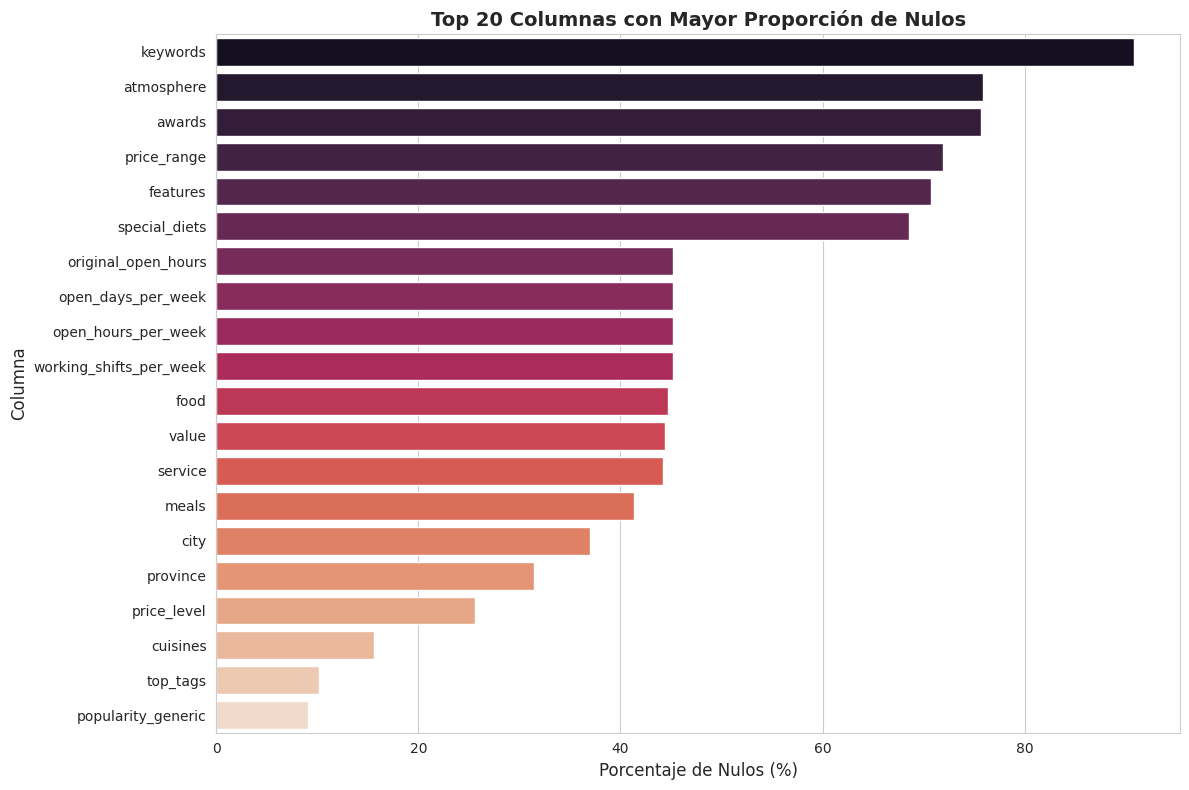


Total de nulos en el dataset: 11,154,480


In [9]:
# Visualizar nulos por columna (top 20)
fig, ax = plt.subplots(figsize=(12, 8))
top_20_missing = missing_rates.head(20)
sns.barplot(x=top_20_missing.values, y=top_20_missing.index, palette='rocket', ax=ax)
ax.set_xlabel('Porcentaje de Nulos (%)', fontsize=12)
ax.set_ylabel('Columna', fontsize=12)
ax.set_title('Top 20 Columnas con Mayor Proporción de Nulos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nTotal de nulos en el dataset: {df.isna().sum().sum():,}")


Distribución de nulos por fila:
Mín: 0.00%
Máx: 73.81%
Media: 24.51%
Mediana: 21.43%


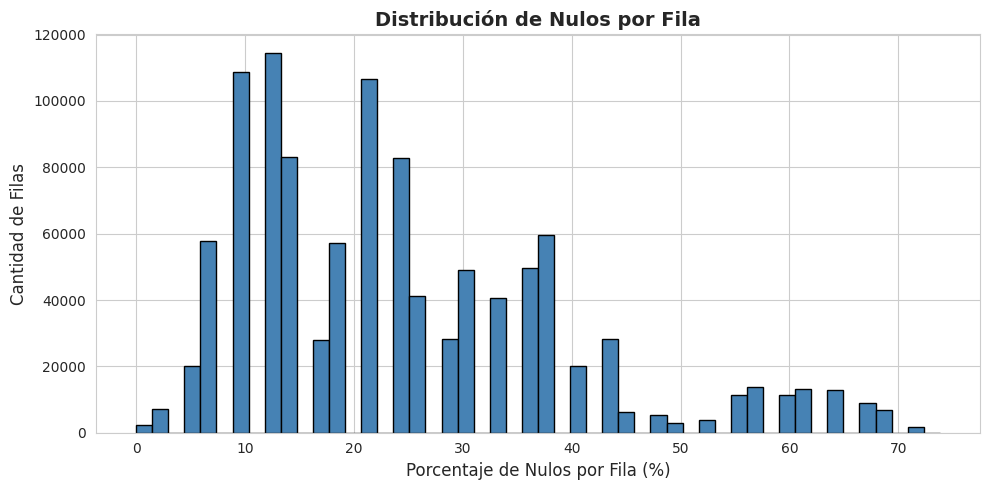

In [10]:
# Distribución de nulos: filas con X% de nulos
null_per_row = (df.isna().sum(axis=1) / df.shape[1] * 100)
print("\nDistribución de nulos por fila:")
print(f"Mín: {null_per_row.min():.2f}%")
print(f"Máx: {null_per_row.max():.2f}%")
print(f"Media: {null_per_row.mean():.2f}%")
print(f"Mediana: {null_per_row.median():.2f}%")

fig, ax = plt.subplots(figsize=(10, 5))
null_per_row.hist(bins=50, ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('Porcentaje de Nulos por Fila (%)', fontsize=12)
ax.set_ylabel('Cantidad de Filas', fontsize=12)
ax.set_title('Distribución de Nulos por Fila', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Análisis por Tipo de Dato

In [11]:
# Separar columnas por tipo
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Columnas numéricas: {len(numeric_cols)}")
print(numeric_cols)
print(f"\nColumnas categóricas: {len(categorical_cols)}")
print(categorical_cols)

Columnas numéricas: 17
['latitude', 'longitude', 'open_days_per_week', 'open_hours_per_week', 'working_shifts_per_week', 'avg_rating', 'total_reviews_count', 'reviews_count_in_default_language', 'excellent', 'very_good', 'average', 'poor', 'terrible', 'food', 'service', 'value', 'atmosphere']

Columnas categóricas: 25
['restaurant_link', 'restaurant_name', 'original_location', 'country', 'region', 'province', 'city', 'address', 'claimed', 'awards', 'popularity_detailed', 'popularity_generic', 'top_tags', 'price_level', 'price_range', 'meals', 'cuisines', 'special_diets', 'features', 'vegetarian_friendly', 'vegan_options', 'gluten_free', 'original_open_hours', 'default_language', 'keywords']


/tmp/ipykernel_4436/2987481020.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


In [12]:
# Estadísticas descriptivas - numéricas
print("\nEstadísticas Descriptivas (Columnas Numéricas):")
df[numeric_cols].describe().round(2)


Estadísticas Descriptivas (Columnas Numéricas):


,latitude,longitude,open_days_per_week,open_hours_per_week,working_shifts_per_week,avg_rating,total_reviews_count,reviews_count_in_default_language,excellent,very_good,average,poor,terrible,food,service,value,atmosphere
count,1067607.00,1067607.00,593832.00,593832.00,593832.00,986761.00,1031162.00,988204.00,988204.00,988204.00,988204.00,988204.00,988204.00,599325.00,604287.00,602692.00,261785.00
mean,46.57,5.84,6.33,62.02,7.63,4.04,102.89,44.56,24.65,10.49,4.11,2.36,2.95,4.10,4.07,3.98,3.93
std,5.88,8.64,0.97,30.54,2.55,0.71,267.24,148.73,89.85,35.51,15.67,9.35,11.03,0.56,0.58,0.58,0.56
min,27.64,-71.22,1.00,0.00,1.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00
25%,41.91,-0.80,6.00,39.00,6.00,3.50,6.00,2.00,1.00,0.00,0.00,0.00,0.00,4.00,4.00,3.50,3.50
50%,46.59,5.65,7.00,58.50,7.00,4.00,24.00,7.00,3.00,2.00,1.00,0.00,0.00,4.00,4.00,4.00,4.00
75%,51.41,12.24,7.00,81.50,7.00,4.50,93.00,26.00,13.00,6.00,2.00,1.00,2.00,4.50,4.50,4.50,4.50
max,69.94,33.37,7.00,168.00,15.00,5.00,52404.00,15229.00,9383.00,4091.00,2132.00,1253.00,1215.00,5.00,5.00,5.00,5.00


In [13]:
# Ubicación geográfica - latitud y longitud
print("\nCobertura Geográfica:")
print(f"Latitud: [{df['latitude'].min():.2f}, {df['latitude'].max():.2f}]")
print(f"Longitud: [{df['longitude'].min():.2f}, {df['longitude'].max():.2f}]")
print(f"Restaurantes con coordenadas válidas: {df[['latitude', 'longitude']].notna().all(axis=1).sum():,}")


Cobertura Geográfica:
Latitud: [27.64, 69.94]
Longitud: [-71.22, 33.37]
Restaurantes con coordenadas válidas: 1,067,607



Distribución de Ratings:
count    986761.00
mean          4.04
std           0.71
min           1.00
25%           3.50
50%           4.00
75%           4.50
max           5.00
Name: avg_rating, dtype: float64


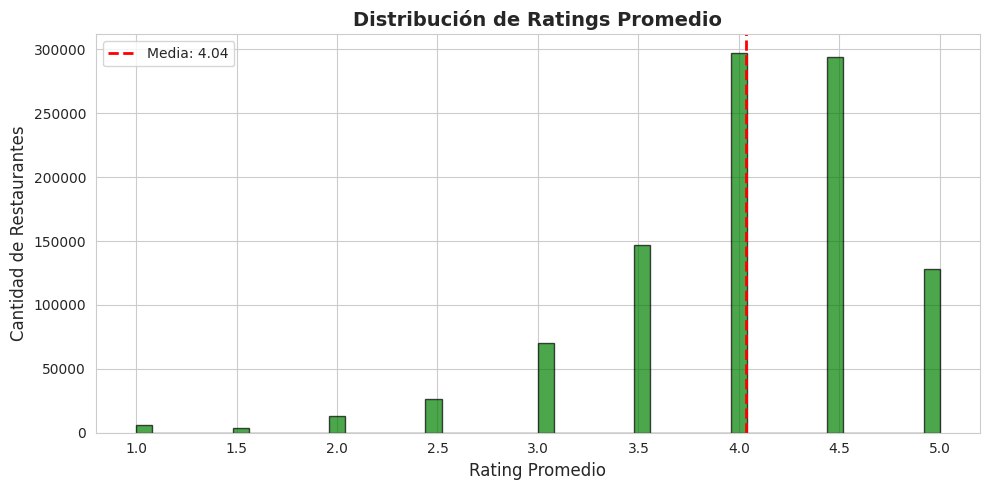

In [14]:
# Ratings
print("\nDistribución de Ratings:")
rating_stats = df['avg_rating'].describe().round(2)
print(rating_stats)

fig, ax = plt.subplots(figsize=(10, 5))
df['avg_rating'].dropna().hist(bins=50, ax=ax, color='green', alpha=0.7, edgecolor='black')
ax.axvline(df['avg_rating'].mean(), color='red', linestyle='--', linewidth=2, label=f"Media: {df['avg_rating'].mean():.2f}")
ax.set_xlabel('Rating Promedio', fontsize=12)
ax.set_ylabel('Cantidad de Restaurantes', fontsize=12)
ax.set_title('Distribución de Ratings Promedio', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Análisis de Datos Categóricos

Top 15 Países con más restaurantes:
country
Italy              224763
Spain              157479
France             155288
England            144681
Germany            115333
Greece              33763
Portugal            32592
The Netherlands     29792
Poland              24698
Belgium             23711
Austria             20487
Sweden              18555
Czech Republic      14844
Scotland            14215
Ireland             11203
Name: count, dtype: int64


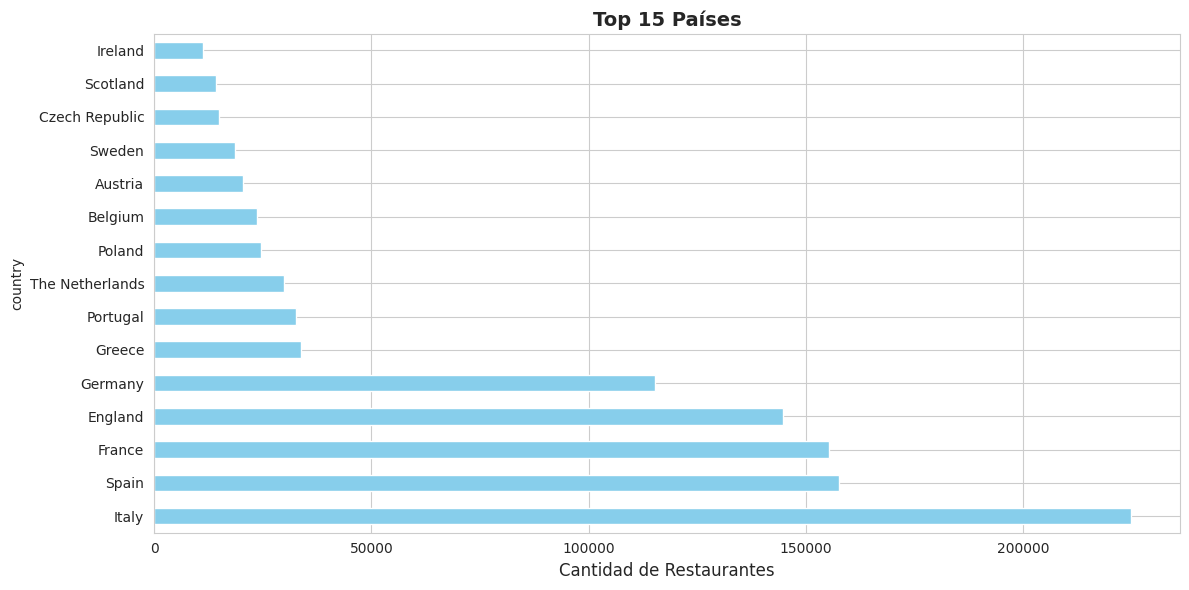

In [15]:
# Top países
print("Top 15 Países con más restaurantes:")
print(df['country'].value_counts().head(15))

fig, ax = plt.subplots(figsize=(12, 6))
df['country'].value_counts().head(15).plot(kind='barh', ax=ax, color='skyblue')
ax.set_xlabel('Cantidad de Restaurantes', fontsize=12)
ax.set_title('Top 15 Países', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
# Top ciudades
print("\nTop 10 Ciudades:")
print(df['city'].value_counts().head(10))


Top 10 Ciudades:
city
Paris        18129
Rome         12603
Madrid       12134
Milan         8382
Prague        6035
Lisbon        5261
Vienna        4571
Amsterdam     4352
Budapest      3557
Munich        3508
Name: count, dtype: int64



Distribución de Nivel de Precio:
price_level
€€-€€€    537918
€         240205
€€€€       28069
Name: count, dtype: int64


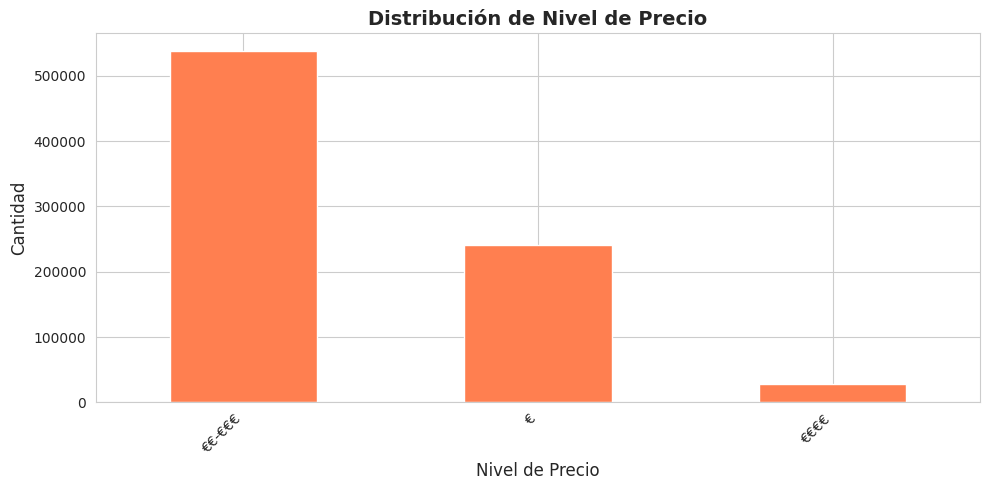

In [17]:
# Categorías de precio (si existen)
print("\nDistribución de Nivel de Precio:")
print(df['price_level'].value_counts().head(10))

fig, ax = plt.subplots(figsize=(10, 5))
df['price_level'].value_counts().head(10).plot(kind='bar', ax=ax, color='coral')
ax.set_xlabel('Nivel de Precio', fontsize=12)
ax.set_ylabel('Cantidad', fontsize=12)
ax.set_title('Distribución de Nivel de Precio', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [18]:
# Opciones vegetarianas y veganas
print("\nOpciones Dietéticas:")
print(f"Vegetarian Friendly: {df['vegetarian_friendly'].value_counts()}")
print(f"\nVegan Options: {df['vegan_options'].value_counts()}")
print(f"\nGluten Free: {df['gluten_free'].value_counts()}")


Opciones Dietéticas:
Vegetarian Friendly: vegetarian_friendly
N    759380
Y    324017
Name: count, dtype: int64

Vegan Options: vegan_options
N    946800
Y    136597
Name: count, dtype: int64

Gluten Free: gluten_free
N    959900
Y    123497
Name: count, dtype: int64


## 6. Análisis de Características Especiales

In [19]:
# Restaurantes con awards
with_awards = df['awards'].notna().sum()
print(f"Restaurantes con premios: {with_awards:,} ({with_awards/len(df)*100:.2f}%)")

# Restaurantes reclamados
claimed = (df['claimed'] == 'True').sum()
print(f"Restaurantes reclamados: {claimed:,} ({claimed/len(df)*100:.2f}%)")

# Restaurantes abiertos
with_hours = df['original_open_hours'].notna().sum()
print(f"Restaurantes con horarios: {with_hours:,} ({with_hours/len(df)*100:.2f}%)")

Restaurantes con premios: 263,133 (24.29%)
Restaurantes reclamados: 0 (0.00%)
Restaurantes con horarios: 593,832 (54.81%)


## 7. Análisis de Reseñas

Estadísticas de Reseñas:
Total de Reseñas (suma): 106,095,216
Promedio de reseñas por restaurante: 102.89
Máximo de reseñas en un restaurante: 52,404
Mediana: 24


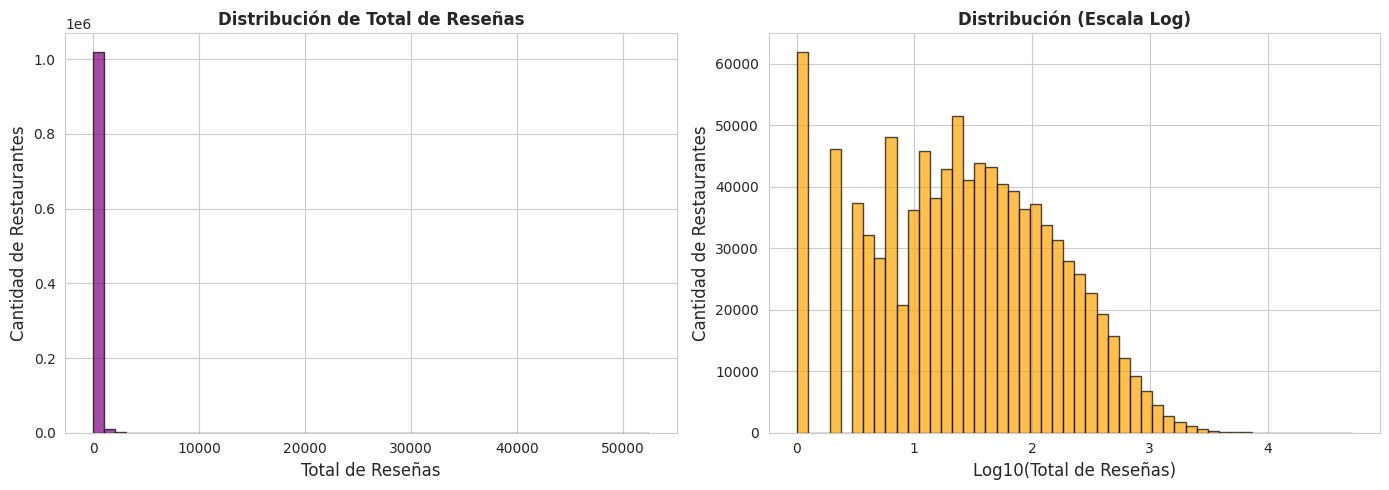

In [20]:
# Estadísticas de reseñas
print("Estadísticas de Reseñas:")
print(f"Total de Reseñas (suma): {df['total_reviews_count'].sum():,.0f}")
print(f"Promedio de reseñas por restaurante: {df['total_reviews_count'].mean():.2f}")
print(f"Máximo de reseñas en un restaurante: {df['total_reviews_count'].max():,.0f}")
print(f"Mediana: {df['total_reviews_count'].median():.0f}")

# Distribución de reseñas (excluir nulos)
reviews_clean = df['total_reviews_count'].dropna()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

reviews_clean.hist(bins=50, ax=ax1, color='purple', alpha=0.7, edgecolor='black')
ax1.set_xlabel('Total de Reseñas', fontsize=12)
ax1.set_ylabel('Cantidad de Restaurantes', fontsize=12)
ax1.set_title('Distribución de Total de Reseñas', fontsize=12, fontweight='bold')

# Escala log para mejor visualización
reviews_non_zero = reviews_clean[reviews_clean > 0]
np.log10(reviews_non_zero).hist(bins=50, ax=ax2, color='orange', alpha=0.7, edgecolor='black')
ax2.set_xlabel('Log10(Total de Reseñas)', fontsize=12)
ax2.set_ylabel('Cantidad de Restaurantes', fontsize=12)
ax2.set_title('Distribución (Escala Log)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [21]:
# Breakdown de ratings
rating_cols = ['excellent', 'very_good', 'average', 'poor', 'terrible']
print("\nBreakdown de Ratings (Reseñas por Categoría):")
for col in rating_cols:
    count = df[col].notna().sum()
    mean_val = df[col].mean()
    print(f"{col}: {count:,} restaurantes, promedio: {mean_val:.1f} reseñas")


Breakdown de Ratings (Reseñas por Categoría):
excellent: 988,204 restaurantes, promedio: 24.7 reseñas
very_good: 988,204 restaurantes, promedio: 10.5 reseñas
average: 988,204 restaurantes, promedio: 4.1 reseñas
poor: 988,204 restaurantes, promedio: 2.4 reseñas
terrible: 988,204 restaurantes, promedio: 3.0 reseñas


## 8. Resumen de Calidad de Datos

In [23]:
# Criar resumen de calidad
quality_summary = {
    'Total Filas': df.shape[0],
    'Total Columnas': df.shape[1],
    'Nulos Totales': int(df.isna().sum().sum()),
    'Columnas sin Nulos': int((df.isna().sum() == 0).sum()),
    'Columnas >50% Nulos': int((missing_rates > 50).sum()),
    'Columnas >70% Nulos': int((missing_rates > 70).sum()),
    'Filas sin Nulos': int((df.isna().sum(axis=1) == 0).sum()),
    'Memoria (MB)': round(df.memory_usage(deep=True).sum() / 1024**2, 2)
}

print("\nRESUMEN DE CALIDAD DE DATOS:")
print("=" * 50)
for key, value in quality_summary.items():
    print(f"{key:.<40} {value}")


RESUMEN DE CALIDAD DE DATOS:
Total Filas............................. 1083397
Total Columnas.......................... 42
Nulos Totales........................... 11154480
Columnas sin Nulos...................... 7
Columnas >50% Nulos..................... 6
Columnas >70% Nulos..................... 5
Filas sin Nulos......................... 2177
Memoria (MB)............................ 1829.97


In [25]:
# Guardar resumen en JSON
output_dir = Path('outputs/eda')
output_dir.mkdir(parents=True, exist_ok=True)

summary_data = {
    'shape': {'rows': df.shape[0], 'columns': df.shape[1]},
    'quality_summary': quality_summary,
    'top_missing_columns': missing_summary.head(15).to_dict('records'),
    'numeric_columns': numeric_cols,
    'categorical_columns': categorical_cols,
}

summary_path = output_dir / 'notebook_eda_summary.json'
with summary_path.open('w', encoding='utf-8') as f:
    json.dump(summary_data, f, ensure_ascii=False, indent=2)

print(f"Resumen guardado en: {summary_path}")

Resumen guardado en: outputs/eda/notebook_eda_summary.json
